<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/Pr%C3%A1ctica_18_Ejercicios_con_EDA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica #18: Ejercicios con EDA 1
Alumno: Marco Antonio Muñoz Quiroz

**Link Github**




**Instrucciones**:

Utiliza el conjunto de datos "Air Quality" disponible al final de esta practica. Este conjunto contiene datos horarios de sensores de calidad del aire, incluyendo niveles de CO, NOx, y otros contaminantes. El conjunto de datos tiene valores faltantes y columnas categóricas (por ejemplo, el día de la semana).




**Hacemos conexion con Google drive y mostramos el dataset**

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Semestre1/Programacion/Semana8/Practica 18/AirQuality.csv', sep=";")
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Convertimos las columnas en los formatos correctos**

In [52]:
# Defino esta funcion solo para imprimir de una forma mas elegante los print("texto")
def print_box(titulo: str): print(f"{'='*(len(titulo)+8)}\n   {titulo}\n{'='*(len(titulo)+8)}\n")

In [53]:
import pandas as pd
import numpy as np

# elimino las dos ultimas columnas ya que no tienen nombre ni datos
df = df.iloc[:, :-2]

# quito todas las filas finales que no contienen ningun registro
# esto hace que el dataset pase de 9741 registros a 9357
df = df.dropna(how="all")

# convierto la columna Date a tipo date usando formato DD/MM/YYYY
df["Date"] = pd.to_datetime(df["Date"].astype(str).str.strip(),
                            format="%d/%m/%Y", errors="coerce").dt.date

# convierto la columna Time a tipo time asumiendo HH.MM.SS con puntos
df["Time"] = pd.to_datetime(df["Time"].astype(str).str.strip(),
                            format="%H.%M.%S", errors="coerce").dt.time

# antes de convertir a float, limpio caracteres raros en todas las columnas excepto Date y Time
cols_excluir = {"Date", "Time"}
for c in df.columns:
    if c in cols_excluir:
        continue

    # paso todo a str y quito espacios
    s = df[c].astype(str).str.strip()

    # unifico decimal a punto
    s = s.str.replace(",", ".", regex=False)

    # si hay puntos de miles y un decimal final, quito todos los puntos excepto el ultimo
    # ejemplo: "1.234.56" -> "1234.56"
    s = s.str.replace(r"\.(?=.*\.)", "", regex=True)

    # quito separadores de miles alternativos: espacios normales, no separables y apostrofes
    s = s.str.replace(r"[ '\u00A0]", "", regex=True)

    # extraigo el primer numero valido (acepto signo, decimales y notacion cientifica)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", expand=False)

    # convierto a numerico; lo que no se pueda parsear queda como NaN
    df[c] = pd.to_numeric(s, errors="coerce").astype(float)

print_box("Tipos de datos")
print(df.dtypes, "\n")

print_box("Muestra los primeros 20 registros del dataset:")
print(df.head(20).to_string(index=False, line_width=1000))


   Tipos de datos

Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object 

   Muestra los primeros 20 registros del dataset:

      Date     Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)    T   RH     AH
2004-03-10 18:00:00     2.6       1360.0     150.0      11.9         1046.0    166.0        1056.0    113.0        1692.0       1268.0 13.6 48.9 0.7578
2004-03-10 19:00:00     2.0       1292.0     112.0       9.4          955.0    103.0        1174.0     92.0        1559.0        972.0 13.3 47.7 0.7255
2004-03-10 20:00:00     2.2       1402.0      88.0       9.0          939.0    131.

In [54]:
# Vemos cuantos -200 hay en cada columna y que porcentaje representa
import pandas as pd

# Contar total de registros
total_registros = len(df)

# Contar valores -200 por columna
conteo_menos200 = (df == -200).sum()

# Calcular porcentaje
porcentaje_menos200 = (conteo_menos200 / total_registros) * 100

# Unir en un DataFrame resumen
resumen_menos200 = pd.DataFrame({
    "Cantidad -200": conteo_menos200,
    "Porcentaje (%)": porcentaje_menos200.round(2)
})

print("Total de registros en el dataset:", total_registros)
print(resumen_menos200)


Total de registros en el dataset: 9357
               Cantidad -200  Porcentaje (%)
Date                       0            0.00
Time                       0            0.00
CO(GT)                  1683           17.99
PT08.S1(CO)              366            3.91
NMHC(GT)                8443           90.23
C6H6(GT)                 366            3.91
PT08.S2(NMHC)            366            3.91
NOx(GT)                 1639           17.52
PT08.S3(NOx)             366            3.91
NO2(GT)                 1642           17.55
PT08.S4(NO2)             366            3.91
PT08.S5(O3)              366            3.91
T                        366            3.91
RH                       366            3.91
AH                       366            3.91


# **2 - Realizar un EDA completo**

**2.1 Descripcion de los datos**

In [55]:
# Saco las estadisticas basicas solo de las columnas numericas (quito Date y Time)
descripcion = df.iloc[:, 2:].describe().T

# Agrego la mediana porque describe no la incluye
descripcion["mediana"] = df.iloc[:, 2:].median(numeric_only=True)

# Agrego la moda (tomo la primera por si hay varias)
descripcion["moda"] = df.iloc[:, 2:].mode(numeric_only=True).iloc[0]

# Reseteo el indice para que aparezca el nombre de la columna
descripcion = descripcion.reset_index().rename(columns={"index": "Columna"})

# Ordeno las columnas
cols = ["Columna", "count", "mean", "std", "min", "max", "mediana", "moda", "25%", "50%", "75%"]
descripcion = descripcion[cols]

# Imprimo todo en una sola tabla
print_box("Estadísticas descriptivas (sin Date y Time)")
print(descripcion.to_string(index=False, line_width=10000))

print("\nPor los datos del MIN y MODA es facil anticipar posibles outlayers en todas las columnas\n")

   Estadísticas descriptivas (sin Date y Time)

      Columna  count        mean        std    min      max   mediana   moda       25%       50%       75%
       CO(GT) 9357.0  -34.207524  77.657170 -200.0   11.900    1.5000 -200.0    0.6000    1.5000    2.6000
  PT08.S1(CO) 9357.0 1048.990061 329.832710 -200.0 2040.000 1053.0000 -200.0  921.0000 1053.0000 1221.0000
     NMHC(GT) 9357.0 -159.090093 139.789093 -200.0 1189.000 -200.0000 -200.0 -200.0000 -200.0000 -200.0000
     C6H6(GT) 9357.0    1.865683  41.380206 -200.0   63.700    7.9000 -200.0    4.0000    7.9000   13.6000
PT08.S2(NMHC) 9357.0  894.595276 342.333252 -200.0 2214.000  895.0000 -200.0  711.0000  895.0000 1105.0000
      NOx(GT) 9357.0  168.616971 257.433866 -200.0 1479.000  141.0000 -200.0   50.0000  141.0000  284.0000
 PT08.S3(NOx) 9357.0  794.990168 321.993552 -200.0 2683.000  794.0000 -200.0  637.0000  794.0000  960.0000
      NO2(GT) 9357.0   58.148873 126.940455 -200.0  340.000   96.0000 -200.0   53.0000   96.0000

**2.2 Histogramas para las columnas numericas**

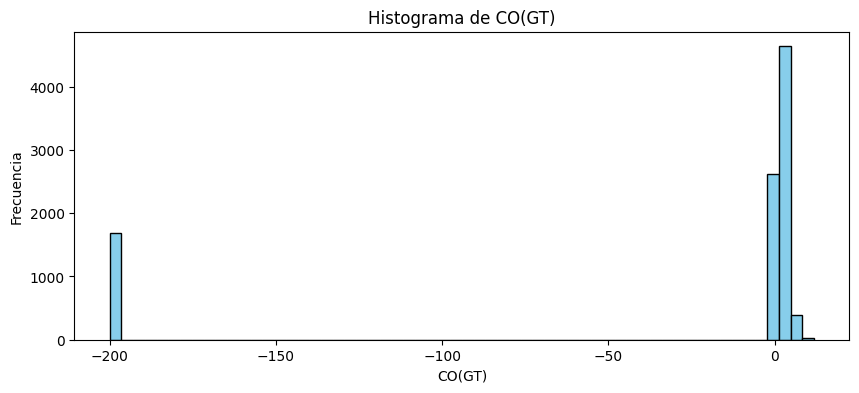

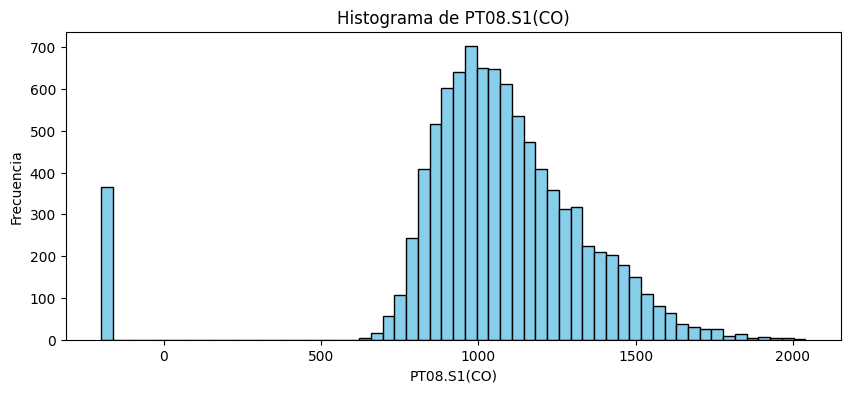

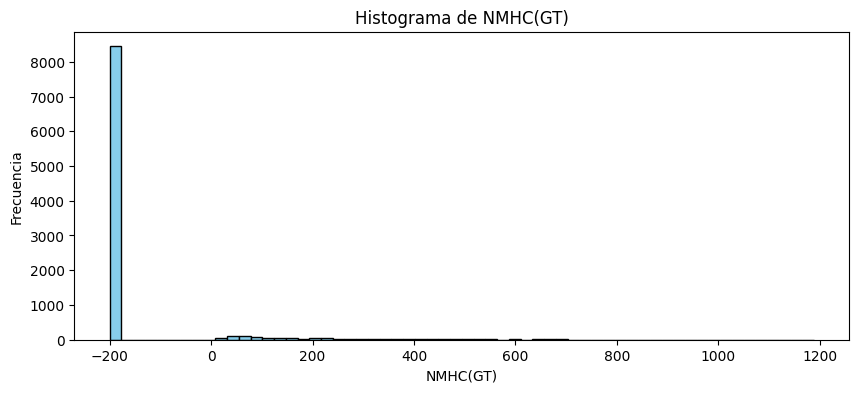

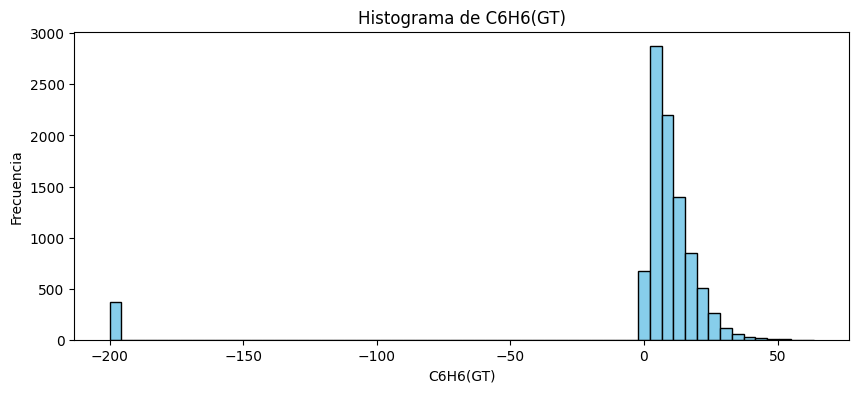

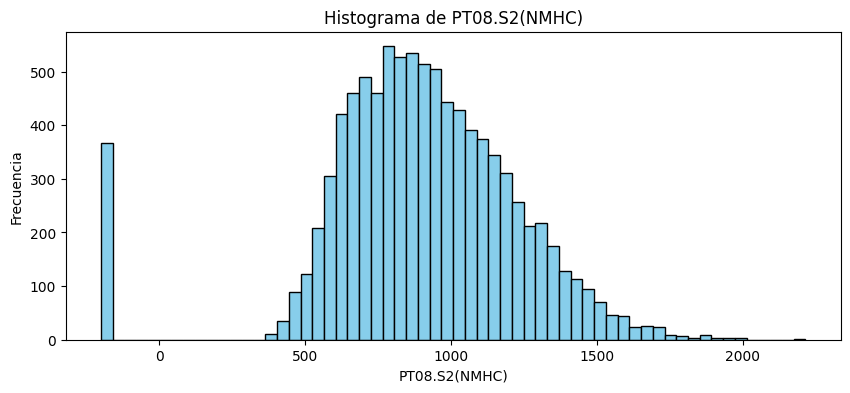

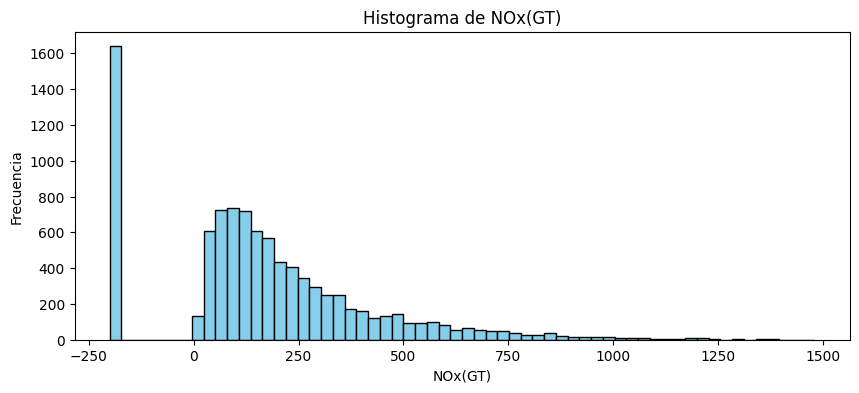

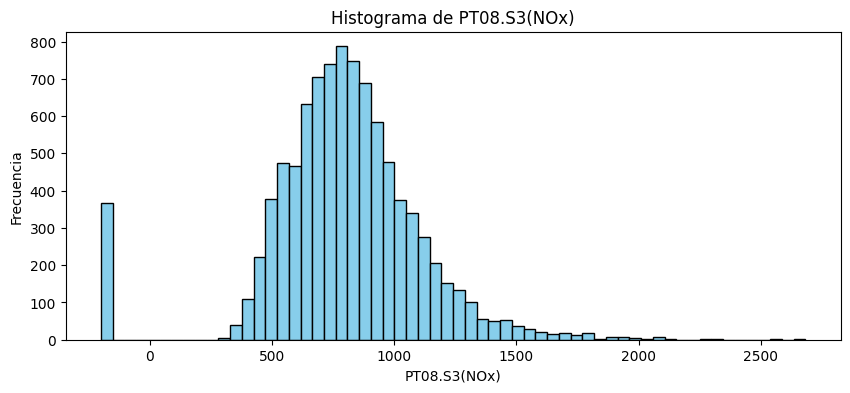

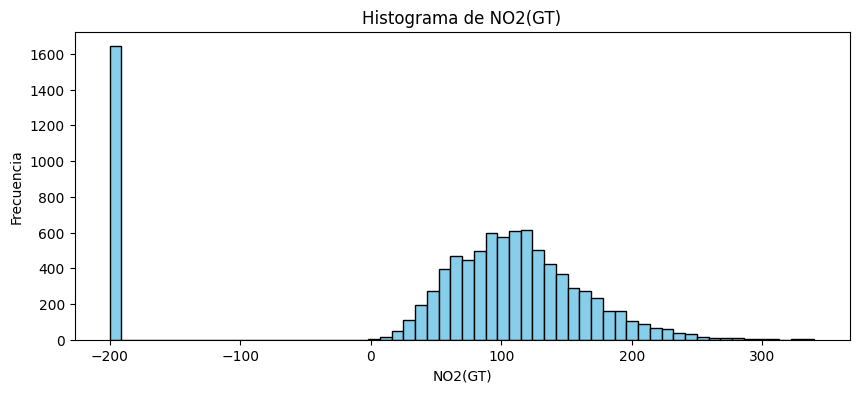

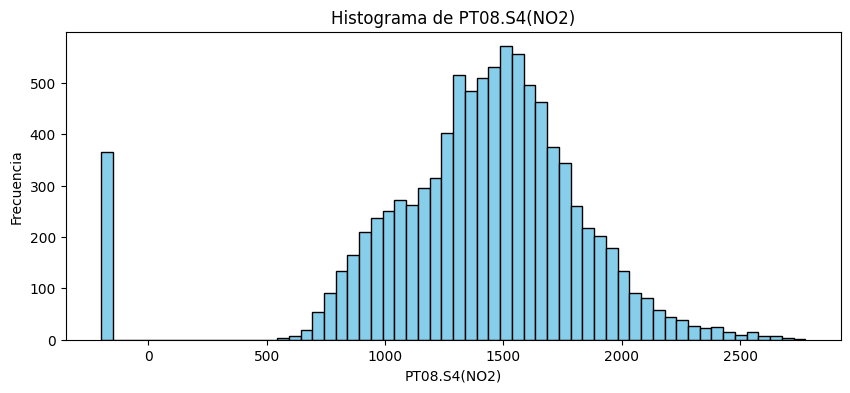

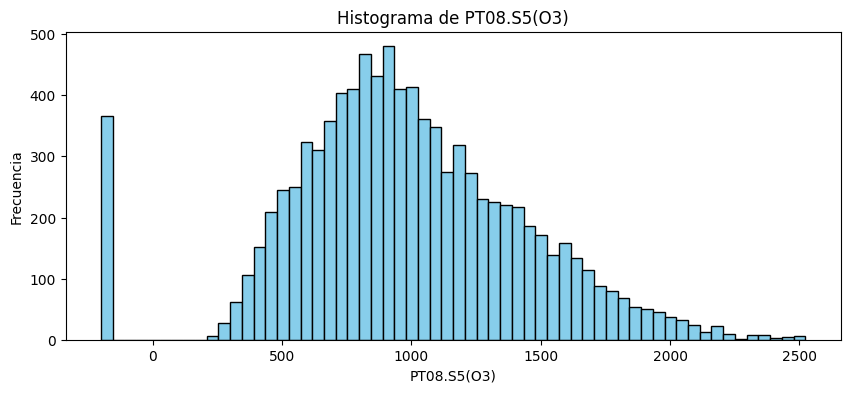

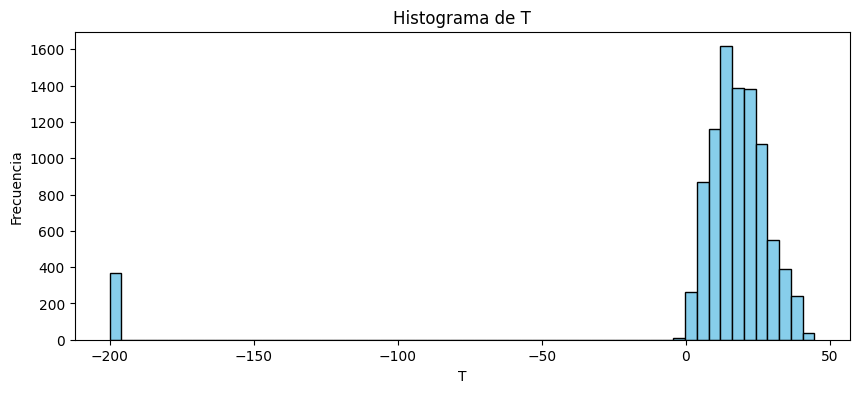

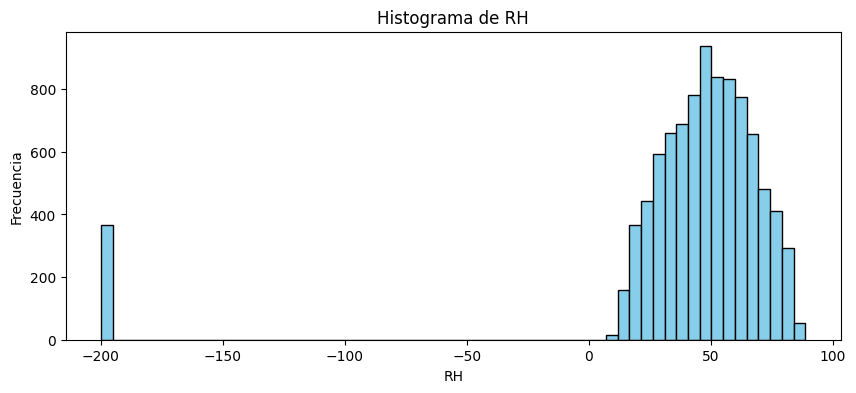

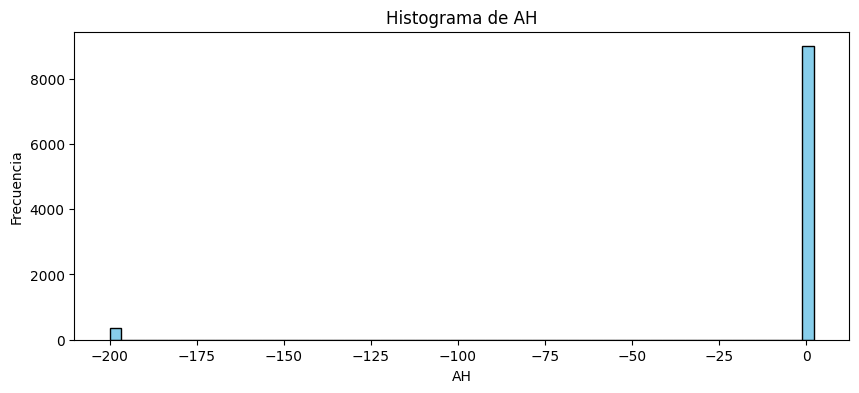

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

for col in df.columns[2:]:
    plt.figure(figsize=(10,4))
    plt.hist(df[col].dropna(), bins=60, edgecolor="black", color="skyblue")
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

**2.3 Gráficas de barras para las columnas categóricas (por ejemplo, DayOfWeek)**

**2.4 Boxplots para identificar outliers en las columnas numéricas**

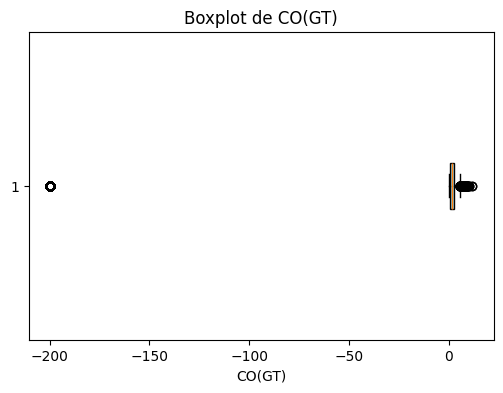

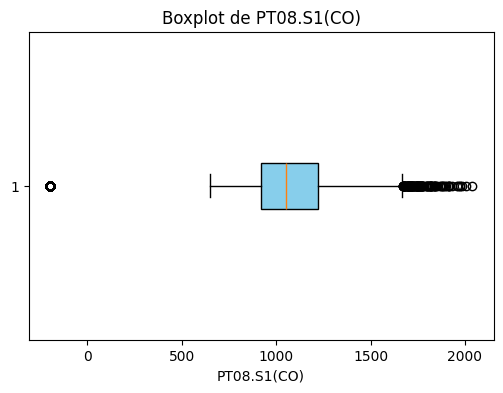

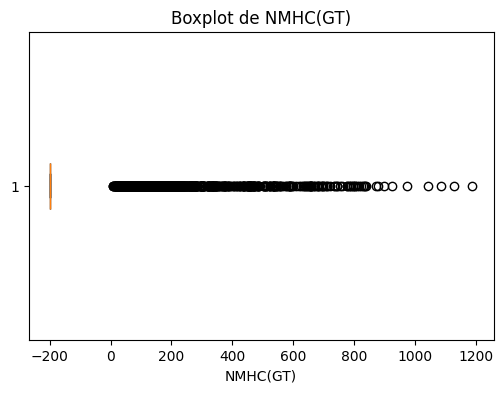

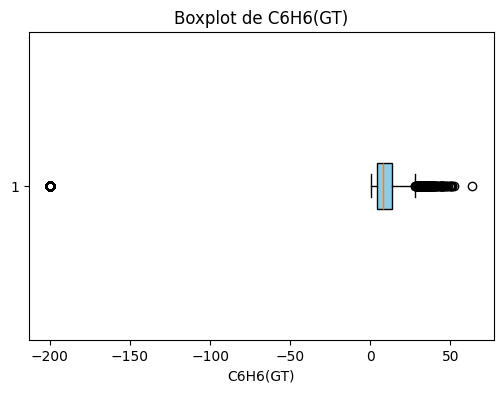

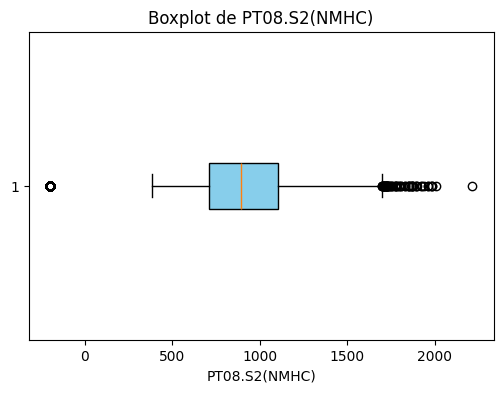

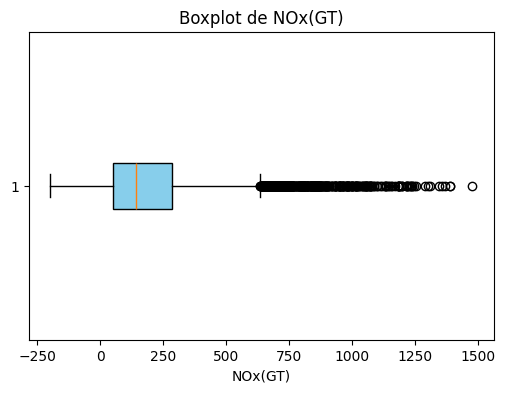

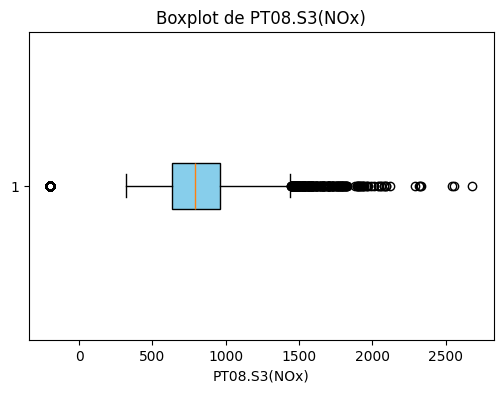

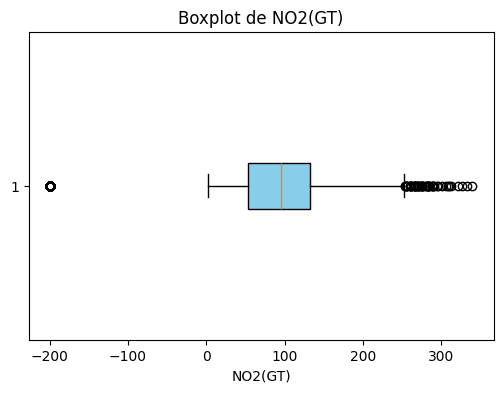

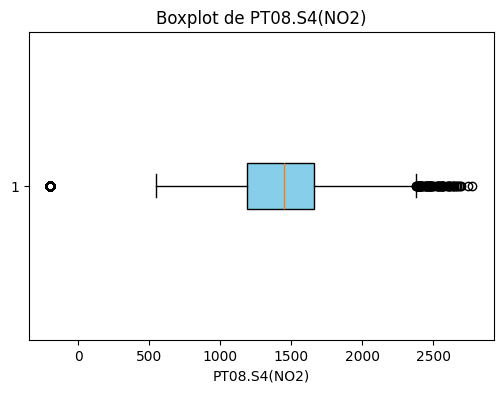

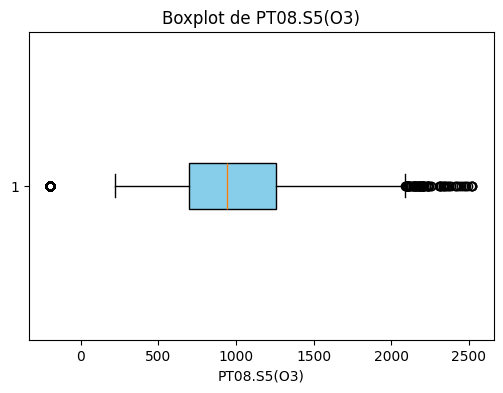

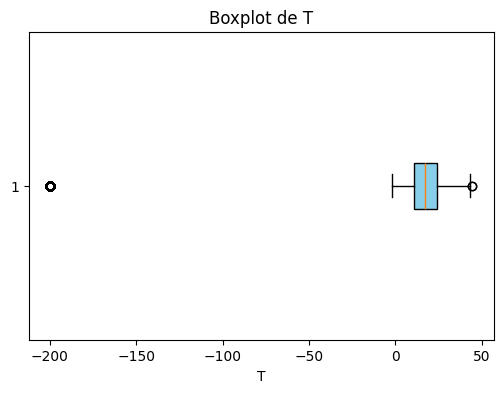

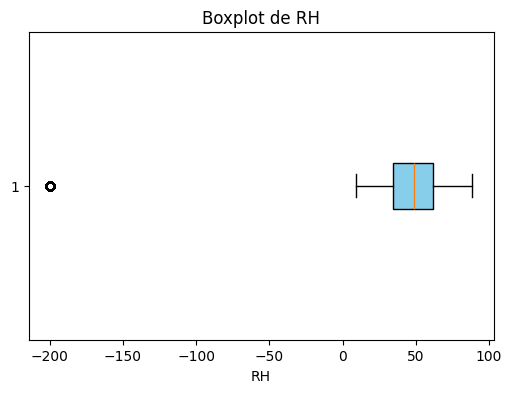

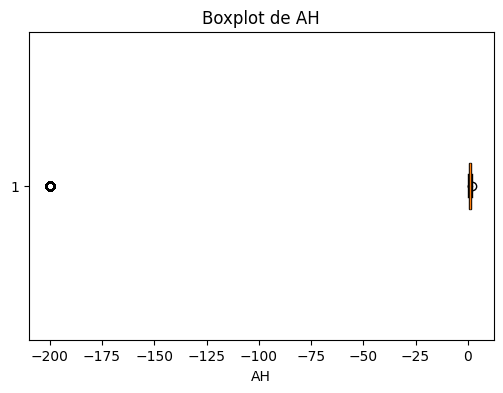

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Recorro todas las columnas numericas (excepto Date y Time)
for i, col in enumerate(df.columns[2:]):
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor="skyblue"))
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

**2.5 Matriz de correlación y mapa de calor**

   Matriz de correlacion:

      Columna    CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)   NOx(GT)  PT08.S3(NOx)   NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)         T        RH        AH
       CO(GT)  1.000000     0.041411  0.128351 -0.031378       0.029926  0.526451     -0.089981  0.671127     -0.073724     0.080310 -0.068939 -0.048227 -0.045892
  PT08.S1(CO)  0.041411     1.000000  0.170007  0.852687       0.933102  0.277993      0.087019  0.154030      0.845149     0.892434  0.754844  0.745375  0.764903
     NMHC(GT)  0.128351     0.170007  1.000000  0.037323       0.110104 -0.004427      0.048821  0.103307      0.162680     0.101185 -0.000009  0.008284  0.012500
     C6H6(GT) -0.031378     0.852687  0.037323  1.000000       0.767433 -0.001174      0.512193 -0.010992      0.774673     0.641334  0.971375  0.925062  0.984555
PT08.S2(NMHC)  0.029926     0.933102  0.110104  0.767433       1.000000  0.331272     -0.073667  0.176488      0.874782     0.909905  0.669025  0.585803  0.64

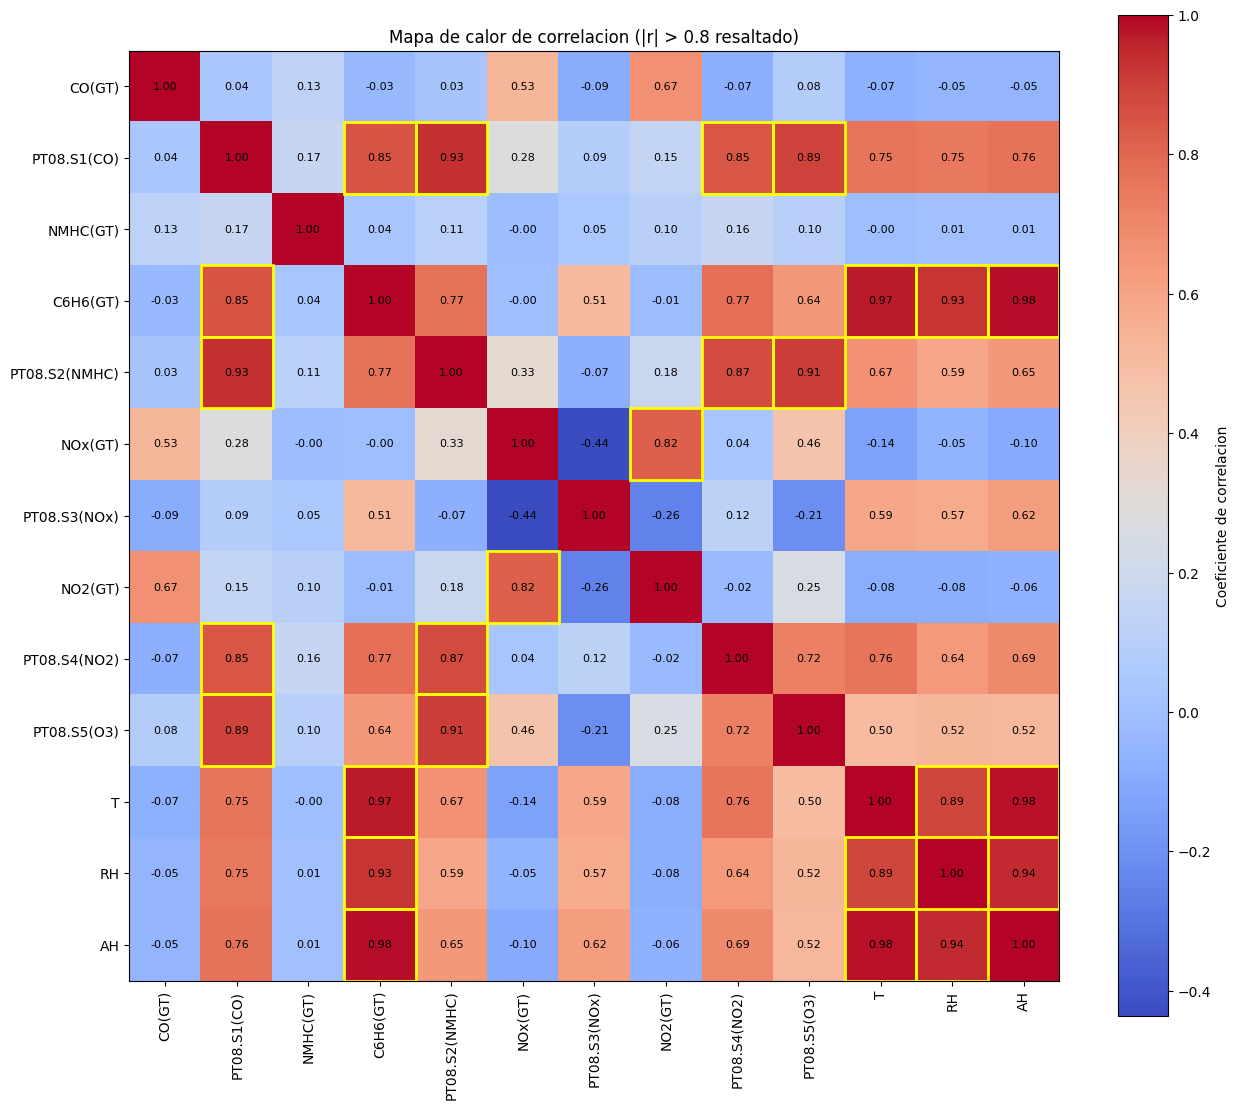


Correlaciones con |r| > 0.8:

C6H6(GT) <-> AH: 0.98
T <-> AH: 0.98
C6H6(GT) <-> T: 0.97
RH <-> AH: 0.94
PT08.S1(CO) <-> PT08.S2(NMHC): 0.93
C6H6(GT) <-> RH: 0.93
PT08.S2(NMHC) <-> PT08.S5(O3): 0.91
PT08.S1(CO) <-> PT08.S5(O3): 0.89
T <-> RH: 0.89
PT08.S2(NMHC) <-> PT08.S4(NO2): 0.87
PT08.S1(CO) <-> C6H6(GT): 0.85
PT08.S1(CO) <-> PT08.S4(NO2): 0.85
NOx(GT) <-> NO2(GT): 0.82


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Defino el umbral que voy a usar para decidir que correlaciones son fuertes
UMBRAL = 0.8

# Calculo la matriz de correlacion solo usando las columnas numericas (quito Date y Time que no son numericas)
corr = df.iloc[:, 2:].corr(method="pearson")

# Convierto la matriz de correlacion a un arreglo numpy para trabajar mas rapido
matriz = corr.values.copy()

# Reemplazo la diagonal de la matriz con NaN para no contar los 1.0 (que siempre son correlaciones perfectas de una variable consigo misma)
np.fill_diagonal(matriz, np.nan)

# Uso np.where para encontrar todas las posiciones (i, j) donde el valor absoluto de la correlacion es mayor al umbral
# np.where devuelve dos listas: una con indices de fila y otra con indices de columna
indices = np.where(np.abs(matriz) > UMBRAL)

# Uso zip(*indices) para combinar esas dos listas en pares (i, j)
# zip junta los elementos de dos listas y con *indices estoy desempaquetando las dos listas que devuelve np.where
pares = list(zip(*indices))

# Preparo la matriz de correlacion con la columna "Columna" para mostrar nombres de variables
corr_print = corr.reset_index().rename(columns={"index": "Columna"})

# Imprimo la matriz de correlacion con nombres de columnas en una columna explicita
print_box("Matriz de correlacion:")
print(corr_print.to_string(index=False, line_width=10000), "\n")

# Ahora dibujo el heatmap
print_box("Mapa de calor:")
plt.figure(figsize=(15, 13))
# Uso imshow para mostrar la matriz de correlacion como una imagen en colores (coolwarm va de azul a rojo)
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Coeficiente de correlacion")
# xticks y yticks sirven para poner el nombre de cada columna como etiqueta en los ejes
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title(f"Mapa de calor de correlacion (|r| > {UMBRAL} resaltado)")

# Recorro toda la matriz con dos ciclos for anidados
# El for externo recorre las filas y el for interno recorre las columnas
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        # Extraigo el valor de correlacion en la posicion (i, j)
        valor = corr.iloc[i, j]
        # Escribo ese valor en el centro de la celda correspondiente usando plt.text
        # ha y va son alineaciones horizontal y vertical para centrar el texto
        plt.text(j, i, f"{valor:.2f}", ha="center", va="center", color="black", fontsize=8)

# Ahora resalto con un recuadro amarillo todas las celdas donde la correlacion es fuerte
for i, j in pares:
    # Rectangle dibuja un rectangulo en la grafica
    # (j-0.5, i-0.5) es la esquina superior izquierda del rectangulo
    # 1, 1 son el ancho y alto (cada celda del heatmap mide 1x1)
    # fill=False hace que solo se dibuje el borde
    # edgecolor="yellow" pone el borde amarillo
    # linewidth=2 define el grosor de la linea del rectangulo
    plt.gca().add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor="yellow", linewidth=2))

plt.show()

# Finalmente imprimo la lista de correlaciones fuertes
print(f"\nCorrelaciones con |r| > {UMBRAL}:\n")
# Aqui uso sorted para ordenar la lista de pares segun el valor absoluto de la correlacion, de mayor a menor
# La funcion lambda ij: abs(corr.iloc[ij[0], ij[1]]) recibe un par (i, j) y devuelve el valor absoluto de corr[i, j]
# reverse=True significa que quiero que el orden sea descendente (primero las mas fuertes)
pares_ordenados = sorted([(i, j) for i, j in pares if i < j],
                         key=lambda ij: abs(corr.iloc[ij[0], ij[1]]),
                         reverse=True)

# Recorro los pares ya ordenados
for i, j in pares_ordenados:
    # Imprimo el nombre de las dos columnas y su correlacion
    print(f"{corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.2f}")


**2.6 Pairplot para visualizar relaciones entre variables numéricas**

   Pairplot de variables numericas:



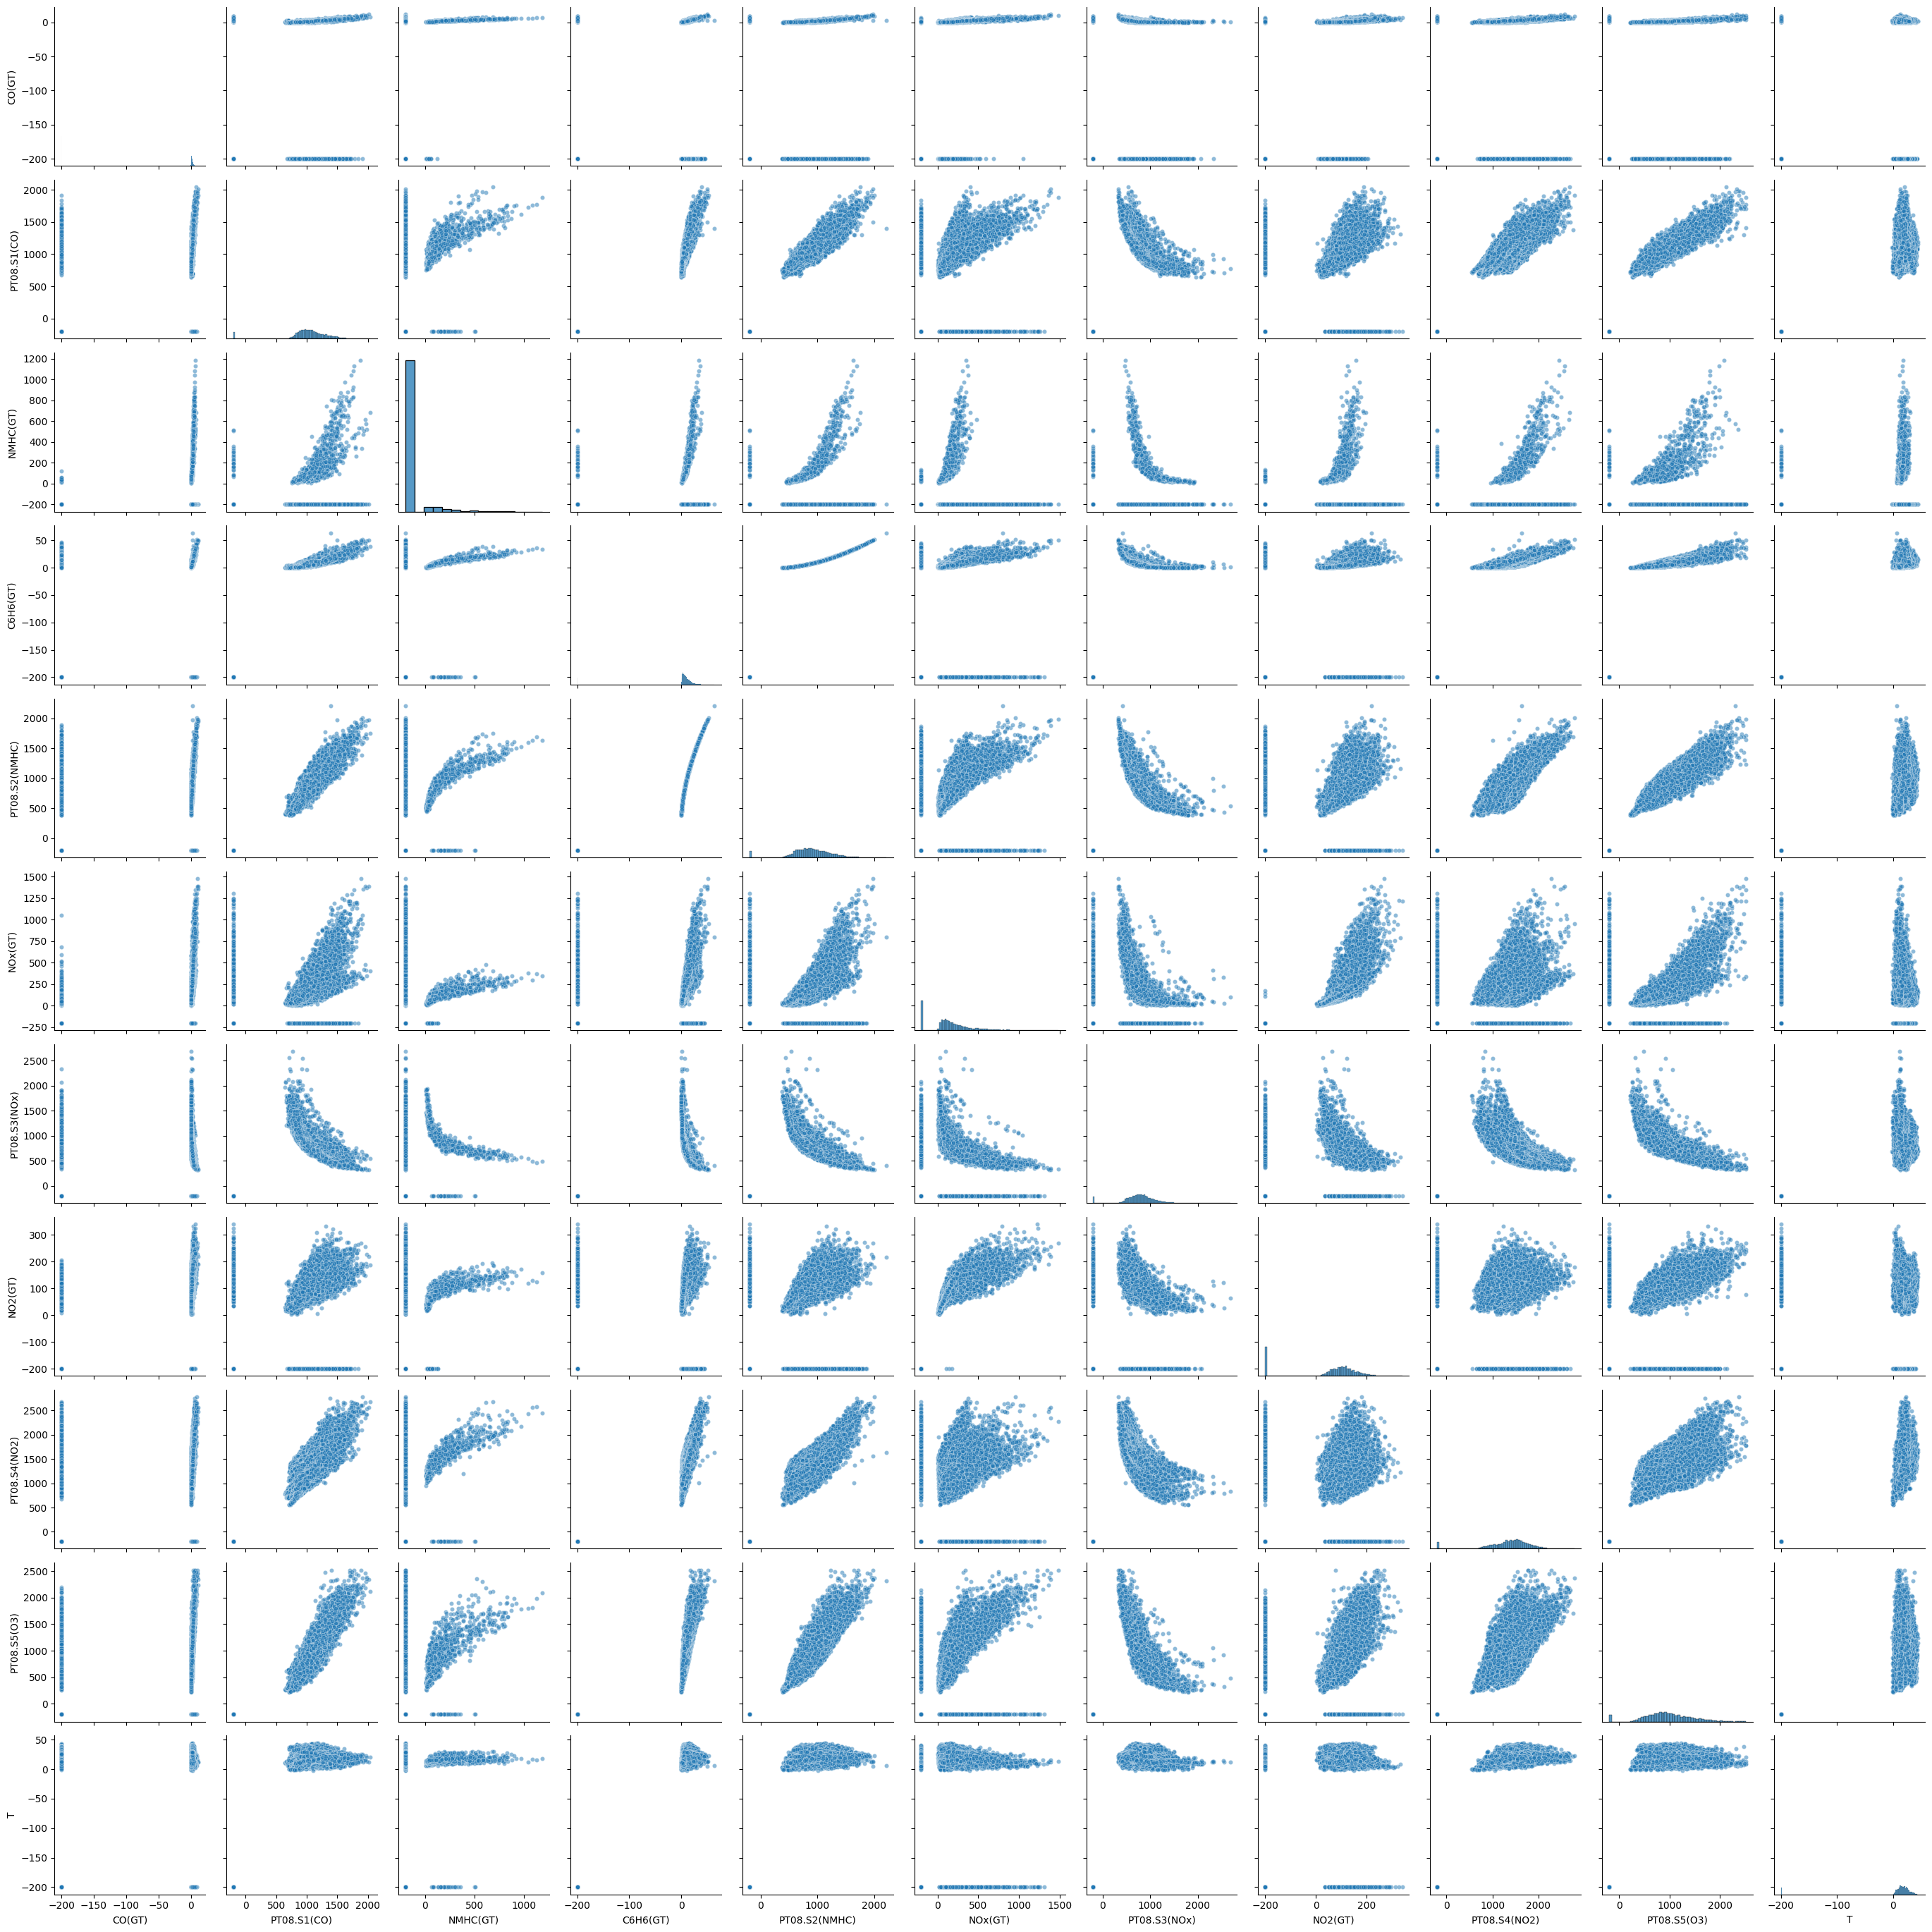

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecciono solo las columnas numericas (quito Date y Time y tambien las dos ultimas para no hacer la grafica tan grande)
df_num = df.iloc[:, 2:-2]

# Hago el pairplot
# diag_kind="hist" pone histogramas en la diagonal
# plot_kws personaliza la apariencia de los scatter
print_box("Pairplot de variables numericas:")
g = sns.pairplot(df_num, diag_kind="hist", plot_kws={"alpha": 0.5, "s": 20})

# Recorro los ejes del pairplot para poner los nombres de columnas
for i, col in enumerate(df_num.columns):
    # Etiquetas de la columna en la diagonal
    g.axes[i, i].set_xlabel(col)
    g.axes[i, i].set_ylabel(col)

# Ajusto el layout para que no se encimen los nombres
plt.tight_layout()
plt.show()

**2.7 Pruebas de normalidad (Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov) y QQplot para las columnas numéricas.**

   Pruebas de normalidad para CO(GT)

n = 9357
Shapiro-Wilk -> estadistico=0.482373, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=2501.153340
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.490811, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9357.
  res = hypotest_fun_out(*samples, **kwds)


<Figure size 600x400 with 0 Axes>

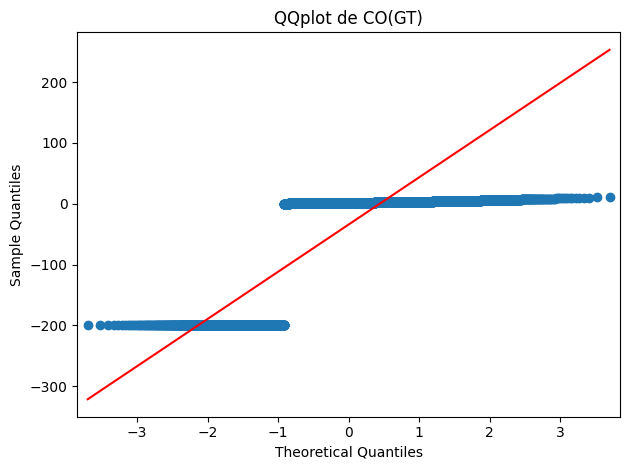

   Pruebas de normalidad para PT08.S1(CO)

n = 9357
Shapiro-Wilk -> estadistico=0.823214, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=355.412461
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.148763, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

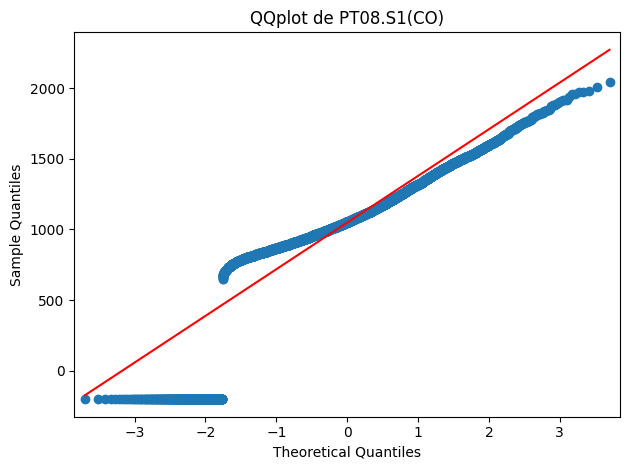

   Pruebas de normalidad para NMHC(GT)

n = 9357
Shapiro-Wilk -> estadistico=0.330694, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=2820.949168
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.517426, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

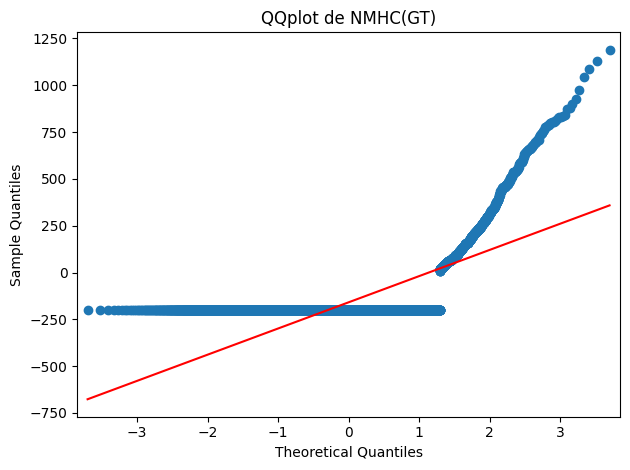

   Pruebas de normalidad para C6H6(GT)

n = 9357
Shapiro-Wilk -> estadistico=0.339425, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=2272.584842
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.444725, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

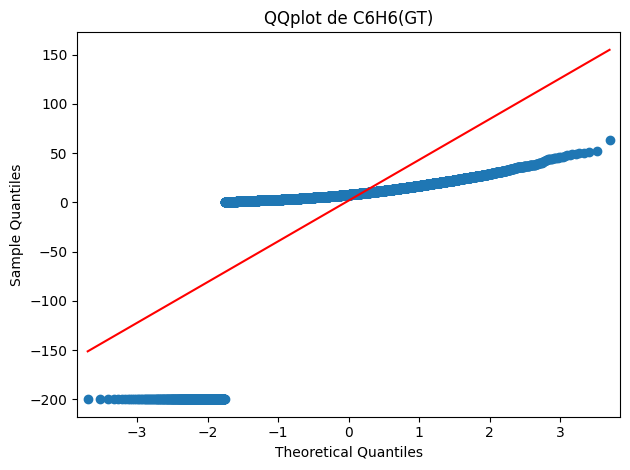

   Pruebas de normalidad para PT08.S2(NMHC)

n = 9357
Shapiro-Wilk -> estadistico=0.931101, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=119.208187
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.080839, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

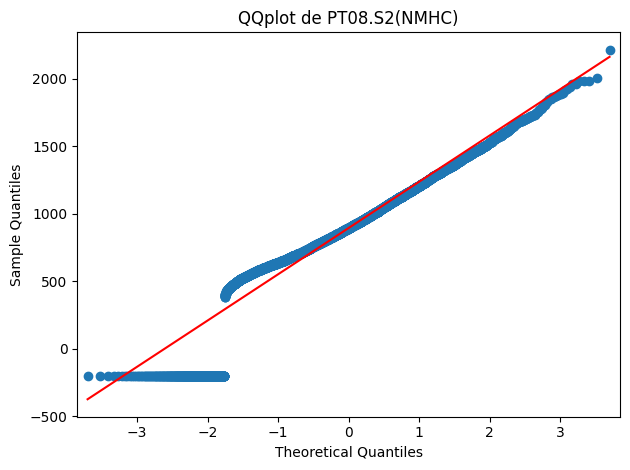

   Pruebas de normalidad para NOx(GT)

n = 9357
Shapiro-Wilk -> estadistico=0.923689, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=188.794285
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.099075, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

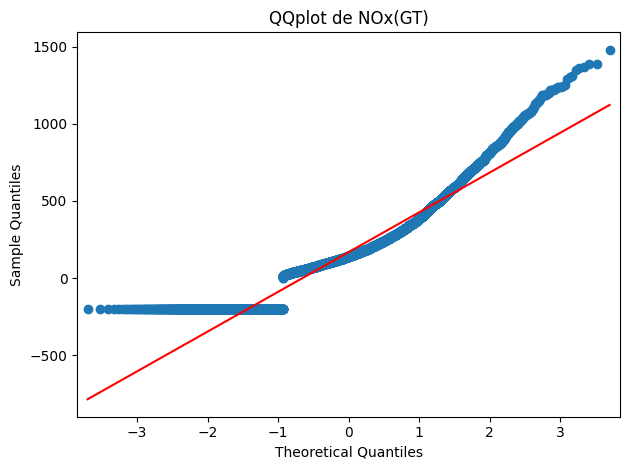

   Pruebas de normalidad para PT08.S3(NOx)

n = 9357
Shapiro-Wilk -> estadistico=0.924983, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=159.031122
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.080568, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

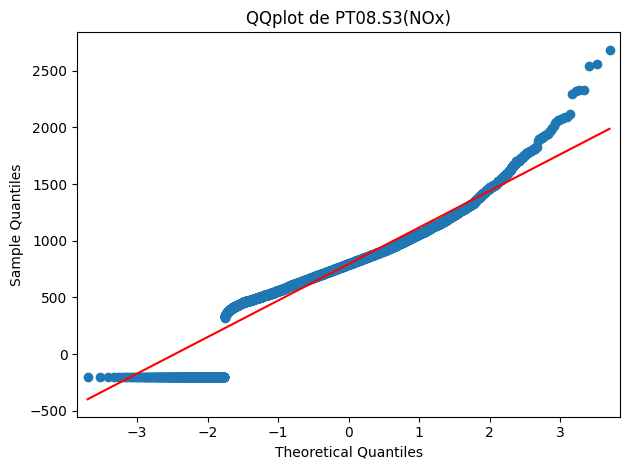

   Pruebas de normalidad para NO2(GT)

n = 9357
Shapiro-Wilk -> estadistico=0.777417, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=894.661635
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.237864, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

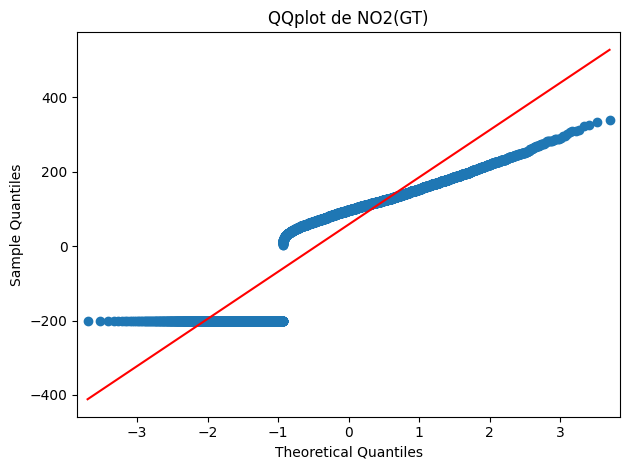

   Pruebas de normalidad para PT08.S4(NO2)

n = 9357
Shapiro-Wilk -> estadistico=0.902383, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=183.341584
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.086718, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

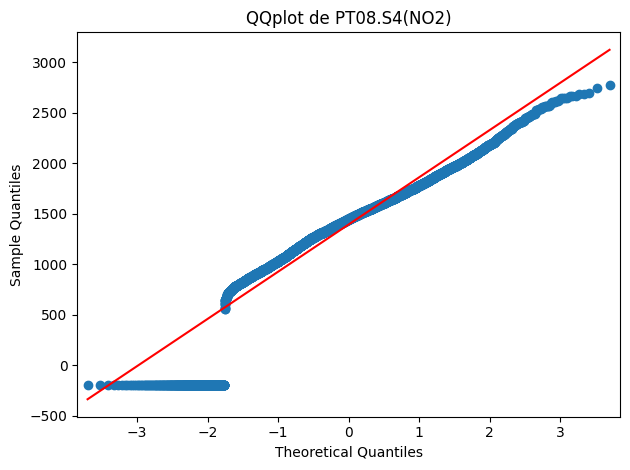

   Pruebas de normalidad para PT08.S5(O3)

n = 9357
Shapiro-Wilk -> estadistico=0.979376, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=45.682343
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.043392, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

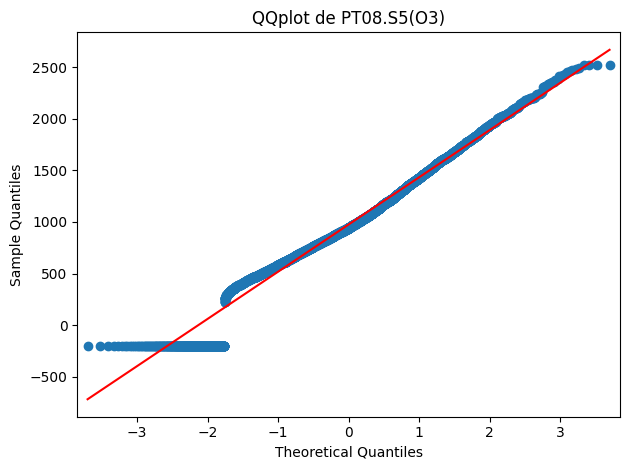

   Pruebas de normalidad para T

n = 9357
Shapiro-Wilk -> estadistico=0.368561, p-valor=0.000000
Conclusion Shapiro-Wilk -> Rechazo normalidad (p < 0.05)
Anderson-Darling -> estadistico=2041.458578
  Nivel 15.0% -> valor critico=0.576000
  Nivel 10.0% -> valor critico=0.656000
  Nivel 5.0% -> valor critico=0.787000
  Nivel 2.5% -> valor critico=0.918000
  Nivel 1.0% -> valor critico=1.092000
Conclusion Anderson-Darling (5%) -> Rechazo normalidad (estadistico > critico 5%)
Kolmogorov-Smirnov -> estadistico=0.384222, p-valor=0.000000
Conclusion Kolmogorov-Smirnov -> Rechazo normalidad (p < 0.05)



<Figure size 600x400 with 0 Axes>

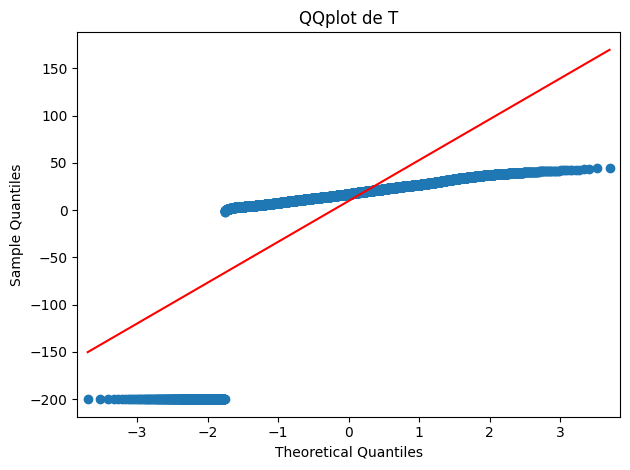

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

# ==============================================================================================================
# ==============================================================================================================
# Prueba de Shapiro-Wilk:
# Esta prueba la uso para ver si una muestra viene de una distribucion normal.
# Me devuelve un estadistico W y un p-valor.
# La hipotesis nula es que los datos son normales.
# Si el p < 0.05 normalmente concluyo que los datos no siguen una normal.

# Prueba de Anderson-Darling:
# Esta prueba mide que tan bien se ajustan mis datos a una distribucion normal.
# Me da un estadistico y varios valores criticos segun niveles de significancia (15%, 10%, 5%, 2.5%, 1%).
# Si el estadistico es mayor que el valor critico en el nivel elegido (por ejemplo 5%),
# rechazo la hipotesis de normalidad.

# Prueba de Kolmogorov-Smirnov (KS):
# Esta prueba compara la distribucion acumulada de mis datos con la distribucion acumulada de una normal teorica.
# En este caso estandarizo mis datos para compararlos contra N(0,1).
# Me devuelve un estadistico D y un p-valor.
# Si el p < 0.05 rechazo la hipotesis de que los datos siguen una normal.

# QQplot:
# Este grafico me permite comparar los cuantiles de mis datos contra los cuantiles de una normal.
# Si los puntos siguen aproximadamente la linea recta, los datos son compatibles con una distribucion normal.
# Si los puntos se desvían mucho de la linea, los datos no son normales.
# ==============================================================================================================
# ==============================================================================================================

# Selecciono solo columnas numericas (quito Date, Time y tambien las dos ultimas para no saturar graficas)
df_num = df.iloc[:, 2:-2]  # dejo menos variables para que el output sea manejable

# Defino nivel alpha para decisiones (lo uso en Shapiro y KS; en Anderson comparo contra critico 5%)
ALPHA = 0.05

for col in df_num.columns:
    # Tomo la serie y quito NaN
    x = df_num[col].dropna()
    n = len(x)

    print_box(f"Pruebas de normalidad para {col}")
    print(f"n = {n}")

    # Shapiro-Wilk (recomendado para n <= 5000 aprox.)
    # Me regresa estadistico W y p-valor
    sh_stat, sh_p = stats.shapiro(x)
    print(f"Shapiro-Wilk -> estadistico={sh_stat:.6f}, p-valor={sh_p:.6f}")
    print("Conclusion Shapiro-Wilk -> " + ("No rechazo normalidad (p >= 0.05)" if sh_p >= ALPHA else "Rechazo normalidad (p < 0.05)"))

    # Anderson-Darling contra normal (no da p-valor, comparo estadistico vs valor critico)
    # Uso el valor critico al 5% para la conclusion principal
    ad_res = stats.anderson(x, dist="norm")
    # Busco el valor critico al 5%
    # ad_res.significance_level suele traer [15, 10, 5, 2.5, 1]
    crit_5 = None
    for crit, sig in zip(ad_res.critical_values, ad_res.significance_level):
        if abs(sig - 5) < 1e-9:
            crit_5 = crit
            break
    print(f"Anderson-Darling -> estadistico={ad_res.statistic:.6f}")
    # Imprimo todos los niveles para referencia
    for crit, sig in zip(ad_res.critical_values, ad_res.significance_level):
        print(f"  Nivel {sig:.1f}% -> valor critico={crit:.6f}")
    if crit_5 is not None:
        concl_ad = "Rechazo normalidad (estadistico > critico 5%)" if ad_res.statistic > crit_5 else "No rechazo normalidad (estadistico <= critico 5%)"
    else:
        concl_ad = "No pude ubicar el valor critico 5%, revisa niveles impresos"
    print(f"Conclusion Anderson-Darling (5%) -> {concl_ad}")

    # Kolmogorov-Smirnov contra N(0,1)
    # Primero estandarizo la muestra (media 0, var 1) para que tenga sentido contra 'norm'
    x_std = (x - x.mean()) / x.std(ddof=1)
    ks_stat, ks_p = stats.kstest(x_std, 'norm')
    print(f"Kolmogorov-Smirnov -> estadistico={ks_stat:.6f}, p-valor={ks_p:.6f}")
    print("Conclusion Kolmogorov-Smirnov -> " + ("No rechazo normalidad (p >= 0.05)" if ks_p >= ALPHA else "Rechazo normalidad (p < 0.05)"))

    print("")  # separador visual

    # QQplot para inspeccion visual
    # Linea='s' dibuja la recta teorica; si los puntos siguen la linea, hay mayor compatibilidad con normalidad
    plt.figure(figsize=(6, 4))
    sm.qqplot(x, line='s')
    plt.title(f"QQplot de {col}")
    plt.tight_layout()
    plt.show()


# **3 - Identificar y tratar los datos faltantes utilizando técnicas como imputación por media, mediana o moda, o eliminación de filas/columnas según sea apropiado**

In [61]:
# Reviso como esta el dataframe actualmente
print_box("Muestra los primeros 20 registros del dataset:")
print(df.head(20).to_string(index=False, line_width=1000))
print("\n")
print_box("Datatypes:")
print(df.dtypes)


   Muestra los primeros 20 registros del dataset:

      Date     Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)    T   RH     AH
2004-03-10 18:00:00     2.6       1360.0     150.0      11.9         1046.0    166.0        1056.0    113.0        1692.0       1268.0 13.6 48.9 0.7578
2004-03-10 19:00:00     2.0       1292.0     112.0       9.4          955.0    103.0        1174.0     92.0        1559.0        972.0 13.3 47.7 0.7255
2004-03-10 20:00:00     2.2       1402.0      88.0       9.0          939.0    131.0        1140.0    114.0        1555.0       1074.0 11.9 54.0 0.7502
2004-03-10 21:00:00     2.2       1376.0      80.0       9.2          948.0    172.0        1092.0    122.0        1584.0       1203.0 11.0 60.0 0.7867
2004-03-10 22:00:00     1.6       1272.0      51.0       6.5          836.0    131.0        1205.0    116.0        1490.0       1110.0 11.2 59.6 0.7888
2004-03-10 23:00:00     1.2       119

In [62]:
import pandas as pd
import numpy as np

# 1) Columnas numéricas y máscara de -200
num_cols = df.columns.difference(["Date", "Time"])
mask_200 = df[num_cols].eq(-200)

# 2) Extraer HORA sin warnings:
#    - Convertimos "HH.MM.SS" -> "HH:MM:SS" y luego parseamos con formato fijo
tstr = df["Time"].astype(str).str.strip().str.replace(".", ":", regex=False)
hour = pd.to_datetime(tstr, format="%H:%M:%S", errors="coerce").dt.hour

# 3) Medianas por hora ignorando -200
tmp = df[num_cols].where(~mask_200, np.nan)          # -200 -> NaN solo para el cálculo de medianas
hourly_median = tmp.groupby(hour).transform("median")# mediana por hora, alineada a filas

# 4) Imputar -200 con mediana por hora
vals = df[num_cols].mask(mask_200, hourly_median)

# 5) Fallback: mediana global por columna (si alguna hora quedó sin datos)
global_median = tmp.median()
remaining = mask_200 & vals.isna()
for c in num_cols:
    vals.loc[remaining[c], c] = global_median[c]

# 6) Escribir de vuelta al DataFrame
df[num_cols] = vals


In [63]:
# imputacion de outliers por IQR usando la mediana por hora como metodo de imputacion
import pandas as pd
import numpy as np

# =========================
# 1) Detectar outliers con IQR
# =========================

# Columnas numéricas
num_cols = df.columns.difference(["Date", "Time"])

# Calculamos Q1, Q3 e IQR
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Límites inferior y superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Creamos una máscara booleana de outliers (a nivel de celda, no fila)
outliers_mask = (df[num_cols] < lower) | (df[num_cols] > upper)

# =========================
# 2) Calcular medianas por hora
# =========================
df["Hour"] = pd.to_datetime(df["Time"].astype(str)).dt.hour
hourly_medians = df.groupby("Hour")[num_cols].transform("median")

# =========================
# 3) Reemplazar outliers por la mediana de su hora
# =========================
outliers_count = outliers_mask.sum().sum()  # total de outliers
df[num_cols] = df[num_cols].mask(outliers_mask, hourly_medians)

# =========================
# 4) Eliminar columna auxiliar Hour
# =========================
df = df.drop(columns=["Hour"])

# =========================
# 5) Reporte
# =========================
print_box("Imputación de outliers por mediana horaria")
print(f"Se imputaron {outliers_count} valores outliers en total.")

# =========================
# 6) Muestra del dataset limpio
# =========================
print_box("Muestra después de imputar outliers (primeras 10 filas)")
print(df.head(10).to_string(index=False, line_width=1000))


   Imputación de outliers por mediana horaria

Se imputaron 2534 valores outliers en total.
   Muestra después de imputar outliers (primeras 10 filas)

      Date     Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)    T   RH     AH
2004-03-10 18:00:00     2.6       1360.0     150.0      11.9         1046.0    166.0        1056.0    113.0        1692.0       1268.0 13.6 48.9 0.7578
2004-03-10 19:00:00     2.0       1292.0     112.0       9.4          955.0    103.0        1174.0     92.0        1559.0        972.0 13.3 47.7 0.7255
2004-03-10 20:00:00     2.2       1402.0      88.0       9.0          939.0    131.0        1140.0    114.0        1555.0       1074.0 11.9 54.0 0.7502
2004-03-10 21:00:00     2.2       1376.0      80.0       9.2          948.0    172.0        1092.0    122.0        1584.0       1203.0 11.0 60.0 0.7867
2004-03-10 22:00:00     1.6       1272.0      51.0       6.5          836.0    131.0    

/tmp/ipython-input-2964044634.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"].astype(str)).dt.hour


# 4 - Repetir el EDA después del tratamiento de datos faltantes y comparar los resultados

**4.1 Descripcion de los datos**

In [64]:
# Saco las estadisticas basicas solo de las columnas numericas (quito Date y Time)
descripcion = df.iloc[:, 2:].describe().T

# Agrego la mediana porque describe no la incluye
descripcion["mediana"] = df.iloc[:, 2:].median(numeric_only=True)

# Agrego la moda (tomo la primera por si hay varias)
descripcion["moda"] = df.iloc[:, 2:].mode(numeric_only=True).iloc[0]

# Reseteo el indice para que aparezca el nombre de la columna
descripcion = descripcion.reset_index().rename(columns={"index": "Columna"})

# Ordeno las columnas
cols = ["Columna", "count", "mean", "std", "min", "max", "mediana", "moda", "25%", "50%", "75%"]
descripcion = descripcion[cols]

# Imprimo todo en una sola tabla
print_box("Estadísticas descriptivas (sin Date y Time)")
print(descripcion.to_string(index=False, line_width=10000))

print("\nPor los datos del MIN y MODA es facil anticipar posibles outlayers en todas las columnas\n")

   Estadísticas descriptivas (sin Date y Time)

      Columna  count        mean        std      min       max   mediana      moda       25%       50%      75%
       CO(GT) 9357.0    1.990221   1.151231   0.1000    5.5000    1.8500    0.6000    1.0000    1.8500    2.700
  PT08.S1(CO) 9357.0 1091.130597 198.720923 647.0000 1655.0000 1068.0000 1236.0000  938.0000 1068.0000 1216.000
     NMHC(GT) 9357.0  187.205408 119.573810   7.0000  457.0000  185.0000  457.0000   71.5000  185.0000  224.000
     C6H6(GT) 9357.0    9.545682   6.212872   0.1000   28.0000    8.3000    2.8000    4.5000    8.3000   13.700
PT08.S2(NMHC) 9357.0  934.138078 253.162195 383.0000 1680.0000  912.0000 1183.0000  736.0000  912.0000 1112.000
      NOx(GT) 9357.0  196.885487 123.543544   2.0000  581.0000  174.0000  118.5000  104.0000  174.0000  268.000
 PT08.S3(NOx) 9357.0  815.879876 213.700383 322.0000 1420.0000  799.0000 1048.0000  662.0000  799.0000  956.000
      NO2(GT) 9357.0  108.582238  40.648015   2.0000  22

**4.2 Histogramas para las columnas numericas**

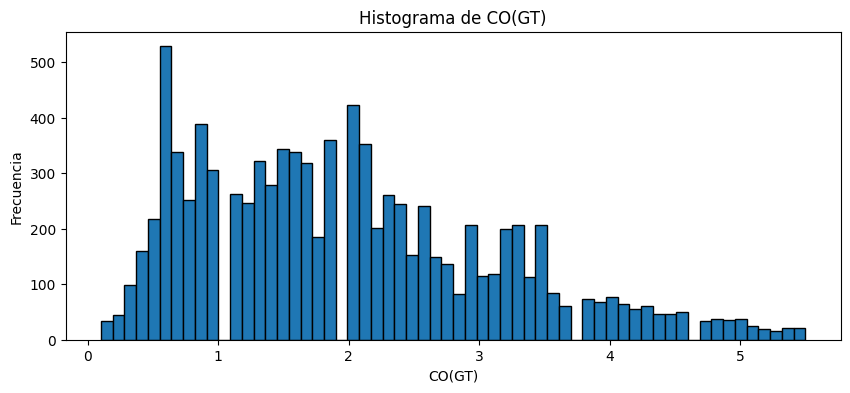

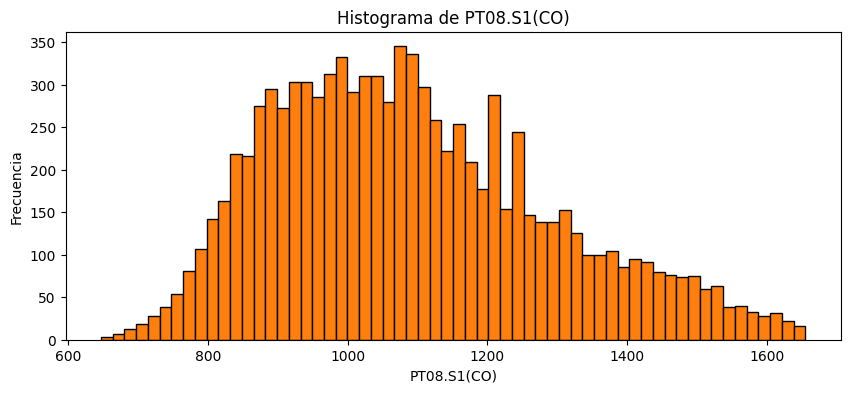

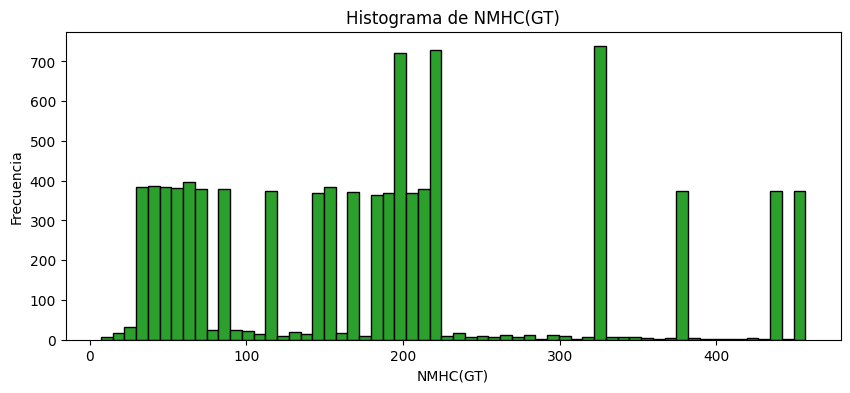

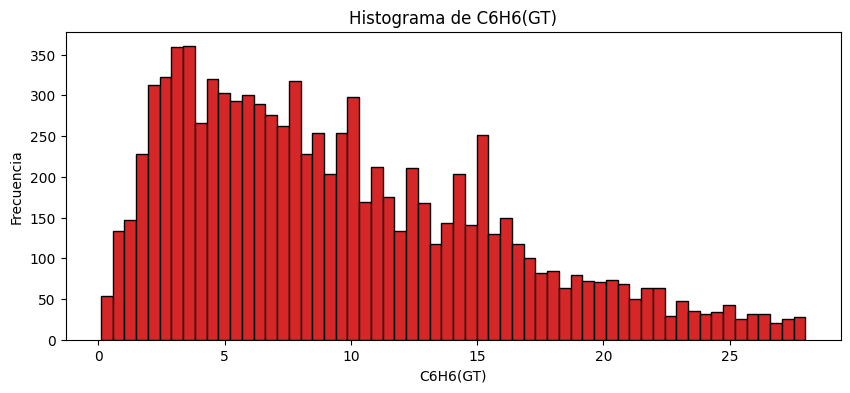

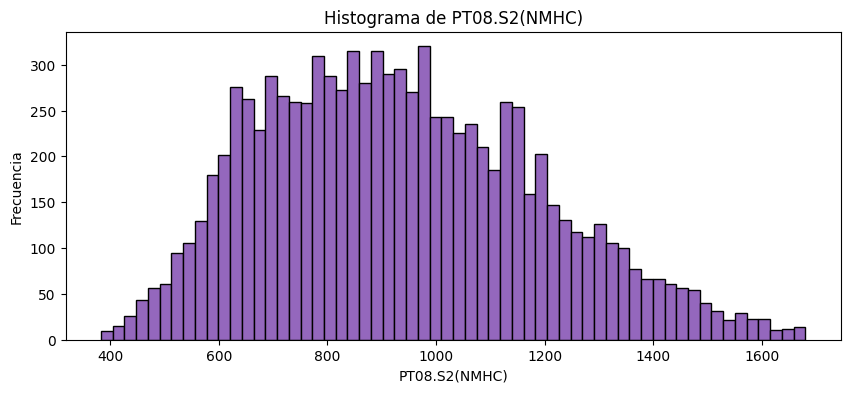

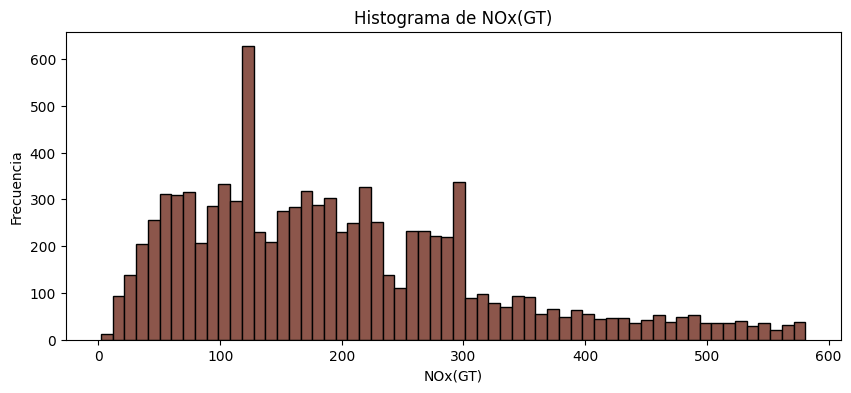

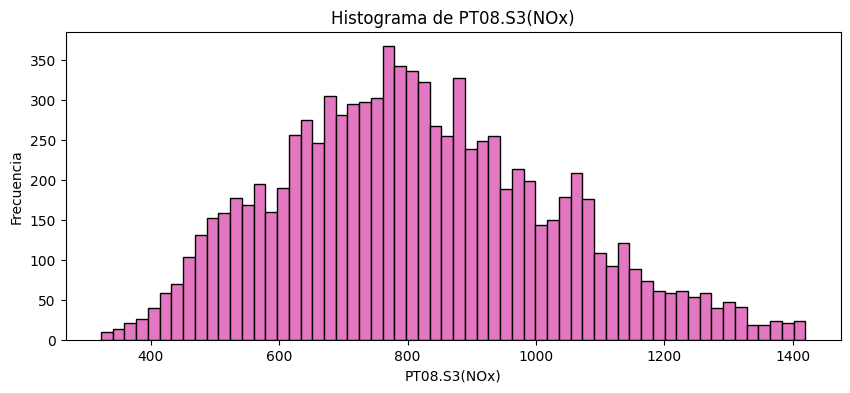

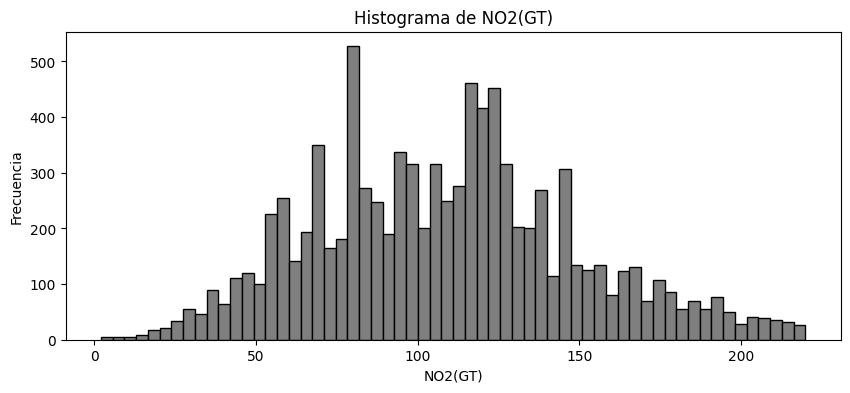

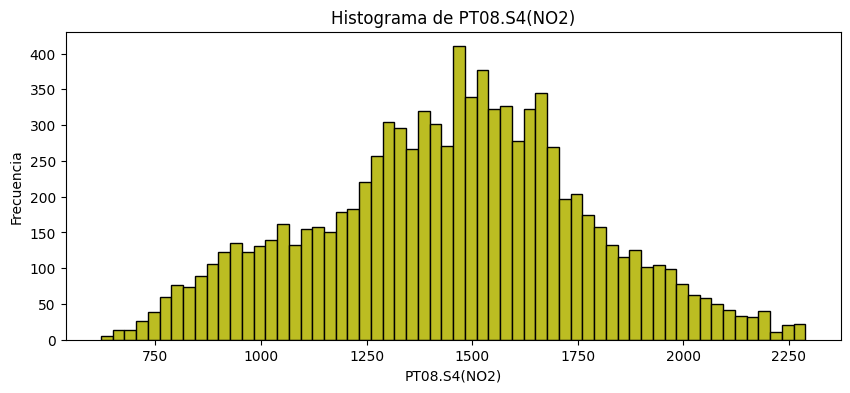

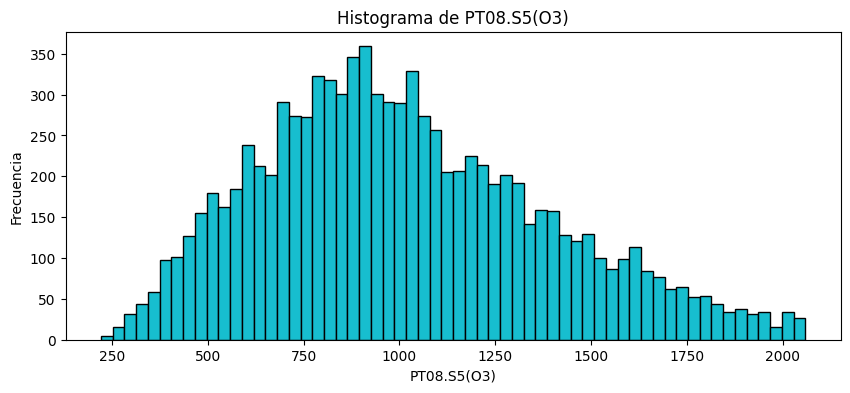

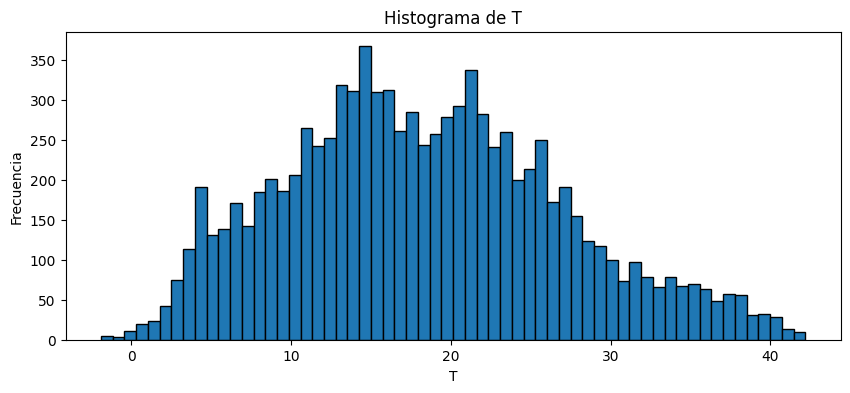

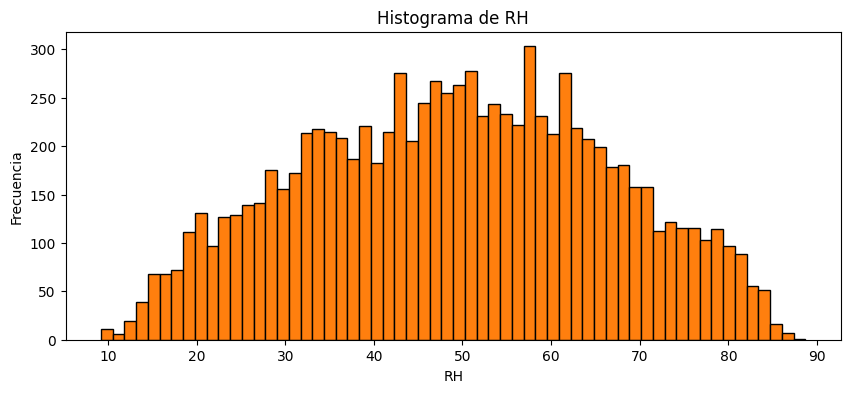

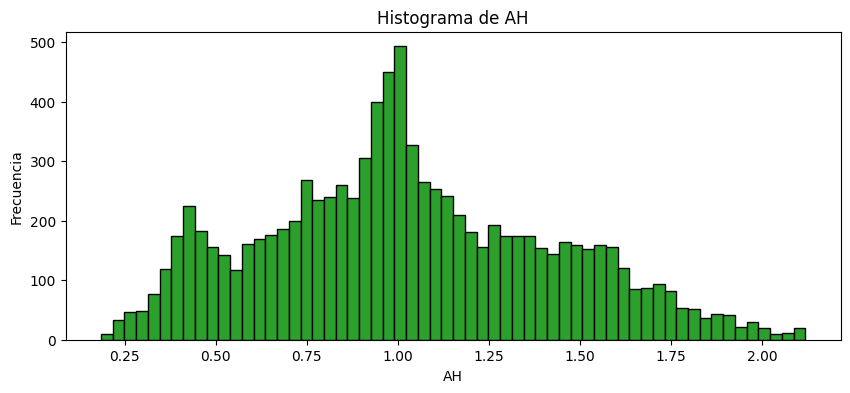

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

colores = plt.cm.tab10.colors
for i, col in enumerate(df.columns[2:]):   # <--- aquí va enumerate
    plt.figure(figsize=(10,4))
    plt.hist(
        df[col].dropna(),
        bins=60,
        edgecolor="black",
        color=colores[i % len(colores)]
    )
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

**4.3 Gráficas de barras para las columnas categóricas (por ejemplo, DayOfWeek)**

**4.4 Boxplots para identificar outliers en las columnas numéricas**

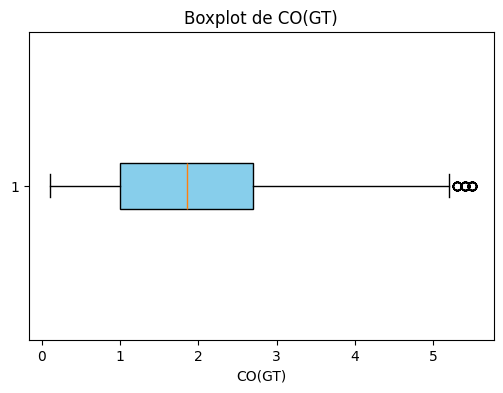

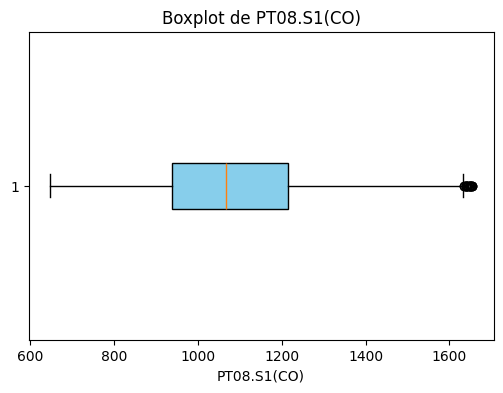

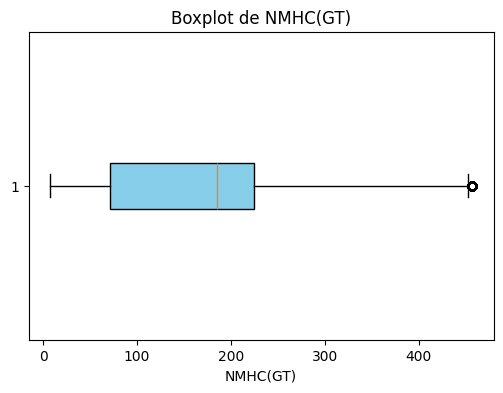

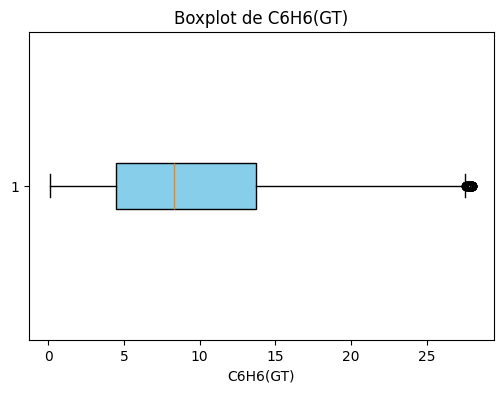

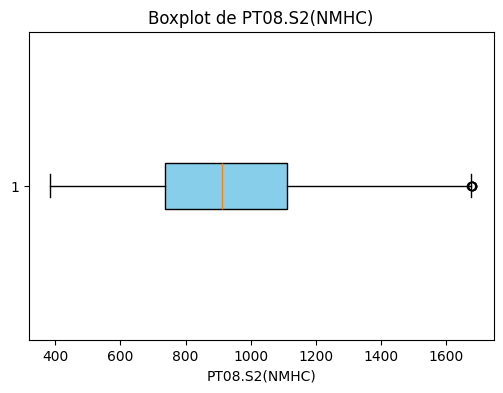

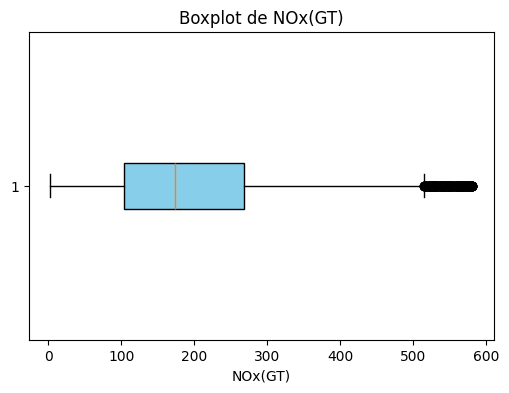

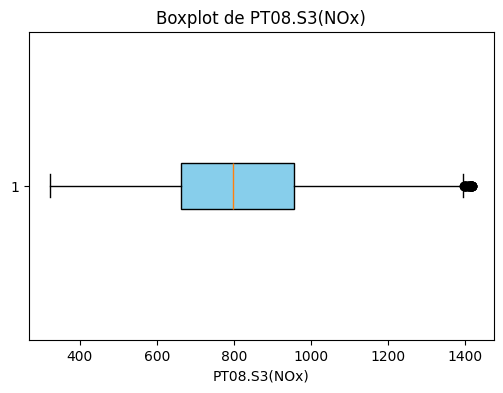

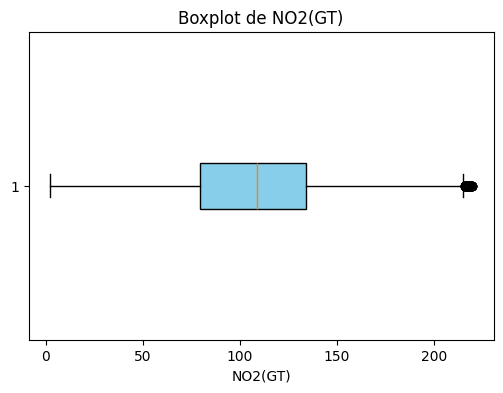

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Recorro todas las columnas numericas (excepto Date y Time)
for i, col in enumerate(df.columns[2:]):
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor="skyblue"))
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

**4.5 Matriz de correlación y mapa de calor**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Defino el umbral que voy a usar para decidir que correlaciones son fuertes
UMBRAL = 0.8

# Calculo la matriz de correlacion solo usando las columnas numericas (quito Date y Time que no son numericas)
corr = df.iloc[:, 2:].corr(method="pearson")

# Convierto la matriz de correlacion a un arreglo numpy para trabajar mas rapido
matriz = corr.values.copy()

# Reemplazo la diagonal de la matriz con NaN para no contar los 1.0 (que siempre son correlaciones perfectas de una variable consigo misma)
np.fill_diagonal(matriz, np.nan)

# Uso np.where para encontrar todas las posiciones (i, j) donde el valor absoluto de la correlacion es mayor al umbral
# np.where devuelve dos listas: una con indices de fila y otra con indices de columna
indices = np.where(np.abs(matriz) > UMBRAL)

# Uso zip(*indices) para combinar esas dos listas en pares (i, j)
# zip junta los elementos de dos listas y con *indices estoy desempaquetando las dos listas que devuelve np.where
pares = list(zip(*indices))

# Preparo la matriz de correlacion con la columna "Columna" para mostrar nombres de variables
corr_print = corr.reset_index().rename(columns={"index": "Columna"})

# Imprimo la matriz de correlacion con nombres de columnas en una columna explicita
print_box("Matriz de correlacion:")
print(corr_print.to_string(index=False, line_width=10000), "\n")

# Ahora dibujo el heatmap
print_box("Mapa de calor:")
plt.figure(figsize=(15, 13))
# Uso imshow para mostrar la matriz de correlacion como una imagen en colores (coolwarm va de azul a rojo)
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Coeficiente de correlacion")
# xticks y yticks sirven para poner el nombre de cada columna como etiqueta en los ejes
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title(f"Mapa de calor de correlacion (|r| > {UMBRAL} resaltado)")

# Recorro toda la matriz con dos ciclos for anidados
# El for externo recorre las filas y el for interno recorre las columnas
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        # Extraigo el valor de correlacion en la posicion (i, j)
        valor = corr.iloc[i, j]
        # Escribo ese valor en el centro de la celda correspondiente usando plt.text
        # ha y va son alineaciones horizontal y vertical para centrar el texto
        plt.text(j, i, f"{valor:.2f}", ha="center", va="center", color="black", fontsize=8)

# Ahora resalto con un recuadro amarillo todas las celdas donde la correlacion es fuerte
for i, j in pares:
    # Rectangle dibuja un rectangulo en la grafica
    # (j-0.5, i-0.5) es la esquina superior izquierda del rectangulo
    # 1, 1 son el ancho y alto (cada celda del heatmap mide 1x1)
    # fill=False hace que solo se dibuje el borde
    # edgecolor="yellow" pone el borde amarillo
    # linewidth=2 define el grosor de la linea del rectangulo
    plt.gca().add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor="yellow", linewidth=2))

plt.show()

# Finalmente imprimo la lista de correlaciones fuertes
print(f"\nCorrelaciones con |r| > {UMBRAL}:\n")
# Aqui uso sorted para ordenar la lista de pares segun el valor absoluto de la correlacion, de mayor a menor
# La funcion lambda ij: abs(corr.iloc[ij[0], ij[1]]) recibe un par (i, j) y devuelve el valor absoluto de corr[i, j]
# reverse=True significa que quiero que el orden sea descendente (primero las mas fuertes)
pares_ordenados = sorted([(i, j) for i, j in pares if i < j],
                         key=lambda ij: abs(corr.iloc[ij[0], ij[1]]),
                         reverse=True)

# Recorro los pares ya ordenados
for i, j in pares_ordenados:
    # Imprimo el nombre de las dos columnas y su correlacion
    print(f"{corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.2f}")


**4.6 Pairplot para visualizar relaciones entre variables numéricas**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecciono solo las columnas numericas (quito Date y Time y tambien las dos ultimas para no hacer la grafica tan grande)
df_num = df.iloc[:, 2:-2]

# Hago el pairplot
# diag_kind="hist" pone histogramas en la diagonal
# plot_kws personaliza la apariencia de los scatter
print_box("Pairplot de variables numericas:")
g = sns.pairplot(df_num, diag_kind="hist", plot_kws={"alpha": 0.5, "s": 20})

# Recorro los ejes del pairplot para poner los nombres de columnas
for i, col in enumerate(df_num.columns):
    # Etiquetas de la columna en la diagonal
    g.axes[i, i].set_xlabel(col)
    g.axes[i, i].set_ylabel(col)

# Ajusto el layout para que no se encimen los nombres
plt.tight_layout()
plt.show()

**4.7 Pruebas de normalidad (Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov) y QQplot para las columnas numéricas.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, anderson, kstest, zscore
import statsmodels.api as sm

# =========================
# 1) Columnas numéricas
# =========================
num_cols = df.columns.difference(["Date", "Time"])

# Diccionario para guardar resultados
resultados = []

# =========================
# 2) Iterar sobre cada columna numérica
# =========================
for col in num_cols:
    data = df[col].dropna()

    # Estandarizar para K-S
    data_z = zscore(data, nan_policy="omit")

    # --- Shapiro-Wilk ---
    if len(data) > 5000:
        muestra = data.sample(5000, random_state=42)
    else:
        muestra = data
    shapiro_stat, shapiro_p = shapiro(muestra)

    # --- Anderson-Darling ---
    ad_result = anderson(data)
    ad_stat = ad_result.statistic
    ad_crit = ad_result.critical_values
    ad_sig = ad_result.significance_level

    # --- Kolmogorov-Smirnov ---
    ks_stat, ks_p = kstest(data_z, 'norm')

    # Guardar resultados
    resultados.append({
        "Columna": col,
        "Shapiro p": shapiro_p,
        "Shapiro Normal?": shapiro_p > 0.05,
        "Anderson stat": ad_stat,
        "AD crit (5%)": ad_crit[2],   # crítico al 5%
        "AD Normal?": ad_stat < ad_crit[2],
        "KS p": ks_p,
        "KS Normal?": ks_p > 0.05
    })

    # --- QQ-plot ---
    sm.qqplot(data_z, line="s")
    plt.title(f"QQ-plot de {col}")
    plt.show()

# =========================
# 3) Convertir a DataFrame
# =========================
resultados_df = pd.DataFrame(resultados)

# Mostrar tabla resumen
print("Resultados de pruebas de normalidad (α=0.05):")
print(resultados_df.to_string(index=False))


In [ ]:
# df.to_csv("test.csv")